In [1]:
# set seeds for reproducibility
import random
random.seed(0)
import numpy as np
np.random.seed(0)




In [2]:
import tensorflow as tf
! pip install tensorflow

Importing the dependencies

In [3]:
from tensorflow.keras import datasets,layers,models
import matplotlib.pyplot as plt


Data Curation

In [4]:
# load and prepare the fashion MNIST dataset
fashion_mnist=datasets.fashion_mnist
(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:

type(train_images)


numpy.ndarray

In [6]:
type(train_labels)
train_labels[:5]

array([9, 0, 0, 3, 0], dtype=uint8)

In [7]:
len(train_images)

60000

In [8]:
len(test_images)

10000

In [9]:
print(train_images[0].shape)

(28, 28)


In [10]:
print(train_images[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0
    0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62
   54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134
  144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178
  107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216
  216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 23

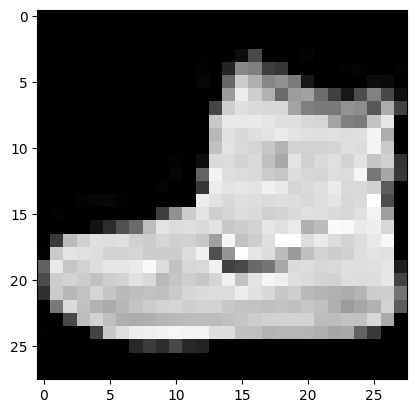

In [11]:
# Display an image from the dataset
plt.imshow(train_images[0],cmap='gray')
plt.show()

In [12]:
class_names=['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

In [13]:
# Normalize pixel values to be between 0 and 1
train_images,test_images=train_images/255.0,test_images/255.0
# confirm the normalization
print('Max: %.3f, Min: %.3f' % (train_images.max(), train_images.min()))

Max: 1.000, Min: 0.000


We reshape the images to add a channel dimension. Most convolutional neural networks (CNNs) expect input in the format (batch_size, height, width, channels). Since our Fashion MNIST images are grayscale, they have only one channel. By reshaping train_images to (train_images.shape[0], 28, 28, 1), we explicitly tell the neural network that each image is 28x28 pixels with 1 color channel, which is a common requirement for these types of models

In [14]:
# Reshape images to specify that it's a single channel (grayscale)
train_images=train_images.reshape((train_images.shape[0],28,28,1))
print(train_images.shape)

(60000, 28, 28, 1)


In [15]:
test_images=test_images.reshape((test_images.shape[0],28,28,1))
print(test_images.shape)

(10000, 28, 28, 1)


Convolutional Neural Network

In [16]:
# Build the convolutuonal base
model=models.Sequential()
model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Conv2D(64,(3,3),activation='relu'))


#Add Dense layers on top
model.add(layers.Flatten())
model.add(layers.Dense(64,activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
# Compile and train the model
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['accuracy']) #here loss func firstly calculate probability from logits(raw numbers from output layer) and then calculate loss

In [18]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop=EarlyStopping(monitor="val_accuracy",patience=2,restore_best_weights=True)

In [19]:
history=model.fit(train_images,train_labels,epochs=10,validation_data=(test_images,test_labels),callbacks=[early_stop])

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.7734 - loss: 0.6316 - val_accuracy: 0.8525 - val_loss: 0.3926
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8580 - loss: 0.4012 - val_accuracy: 0.8752 - val_loss: 0.3339
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8796 - loss: 0.3421 - val_accuracy: 0.8904 - val_loss: 0.3059
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8914 - loss: 0.3069 - val_accuracy: 0.8960 - val_loss: 0.2849
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9006 - loss: 0.2824 - val_accuracy: 0.8989 - val_loss: 0.2842
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9082 - loss: 0.2598 - val_accuracy: 0.9026 - val_loss: 0.2674
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9134 - loss: 0.2417 - val_accuracy: 0.9065 - val_loss: 0.2601
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9175 - loss: 0.2287 -

In [20]:
test_loss,test_acc=model.evaluate(test_images,test_labels,verbose=2)
print("\n Test accuracy:",test_acc)

313/313 - 1s - 2ms/step - accuracy: 0.9105 - loss: 0.2570

 Test accuracy: 0.9104999899864197


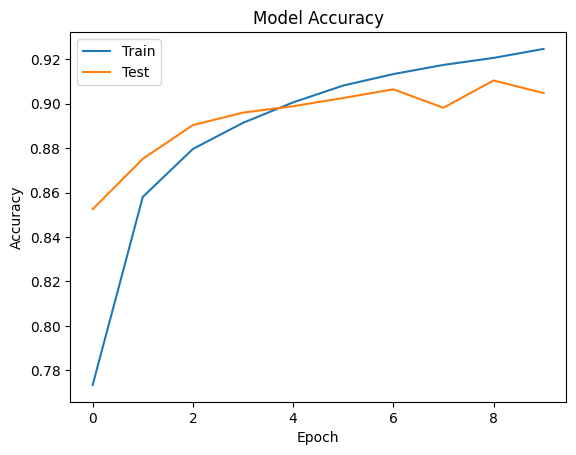

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

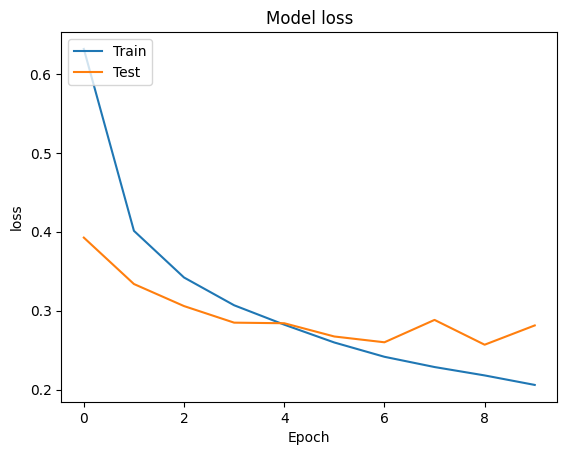

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('loss')
plt.xlabel('Epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

In [23]:
model.save('trained_fashion_mnist_model1.keras')

In [24]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
